# Paper figures

Here we reproduce the figures in the order they appear in the paper.

In [1]:
# Import libraries

from src.spectrogram import *
from src.cost_matrix import *
from src.display import *
from src.spectrogram import *
from src.utils import *

import matplotlib.pyplot as plt

## Fig. 1 - Effects of window length on the spectrogram

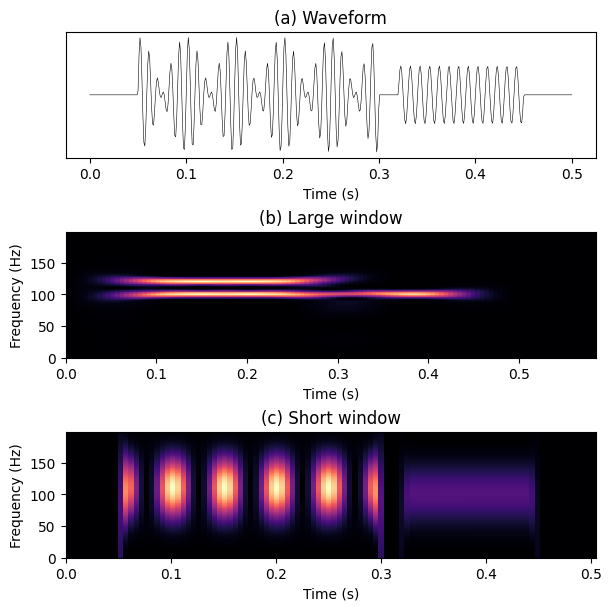

In [2]:
sr = 1000
t, signal = generate_toy_signal(sr)

axes = new_axes(3, 1, figsize=[6, 6]) # 3 row, 1 cols

plot_signal(signal, times=t, ax=axes[0], title='(a) Waveform')

X1 = Spectrogram(signal, sr=sr, window_size_s=180e-3, hop_size_s=5e-3, nfft=1024)
X2 = Spectrogram(signal, sr=sr, window_size_s=20e-3, hop_size_s=5e-3, nfft=1024)

x1 = X1.power_spectrogram()
x2 = X2.power_spectrogram()

display_spectrogram(x1, ax=axes[1], f_bins=X1.f_bins, t_frames=X1.t_bins, high_f=200, title='(b) Large window') # in paper we remove last frames of x1 for readability
display_spectrogram(x2, ax=axes[2], f_bins=X2.f_bins, t_frames=X2.t_bins, high_f=200, title='(c) Short window')

## Fig. 2 - Time-frequency grids used for OT

<Axes: title={'center': '(c) $\\mathcal{S}$'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

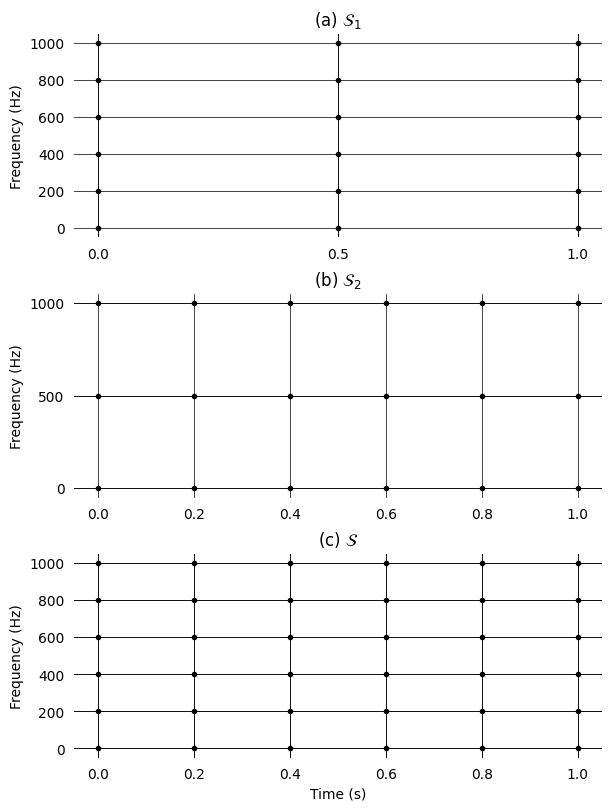

In [3]:
f_bins_1   = np.linspace(0, 1000, 6) # 6 bins from 0 to 1kHz
f_bins_2   = np.linspace(0, 1000, 3) # 3 bins from 0 to 1kHz

t_frames_1 = np.linspace(0, 1, 3) # 3 frames from 0 to 1 second
t_frames_2 = np.linspace(0, 1, 6) # 6 frames from 0 to 1 second

S1, _ = time_freq_support(f_bins_1, t_frames_1)
S2, _ = time_freq_support(f_bins_2, t_frames_2)
S,  _ = time_freq_support(f_bins_1, t_frames_2)

axes = new_axes(3, 1, figsize=[6, 8])

display_support(S1, ax=axes[0], title=r'(a) $\mathcal{S}_1$', xlabel='')
display_support(S2, ax=axes[1], title=r'(b) $\mathcal{S}_2$', xlabel='')
display_support(S , ax=axes[2], title=r'(c) $\mathcal{S}$')

## Fig. 3 - Cost matrices

[]

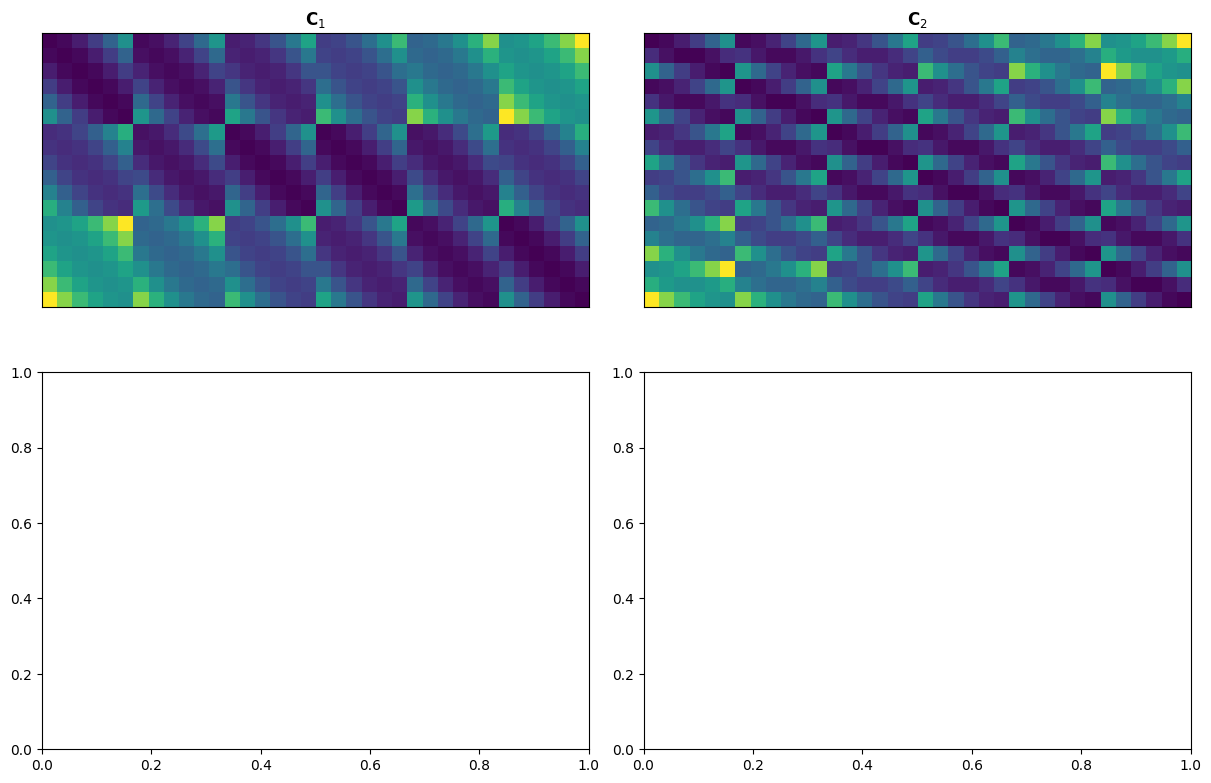

In [11]:
# Reuse supports from previous image

f_bins_1   = np.linspace(0, 1000, 6)
f_bins_2   = np.linspace(0, 1000, 3)

t_frames_1 = np.linspace(0, 1, 3)
t_frames_2 = np.linspace(0, 1, 6)

S1, _ = time_freq_support(f_bins_1, t_frames_1, norm=True) # we activate the norm option to compute cost matrices
S2, _ = time_freq_support(f_bins_2, t_frames_2, norm=True) # this allows for comparison between time (seconds) and frequency (Hz)
S,  _ = time_freq_support(f_bins_1, t_frames_2, norm=True)

C1 = sq_cost_matrix(S1, S)
C2 = sq_cost_matrix(S2, S)

axes = new_axes(2, 2)
axes[0, 0].imshow(C1)
axes[0, 0].set_title(r'$\mathbf{C}_1$')
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])

axes[0, 1].imshow(C2)
axes[0, 1].set_title(r'$\mathbf{C}_2$')
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])